# Explanation with SHAP

## Load model

In [221]:
import joblib
import pandas as pd
import shap
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
import numpy as np

BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

In [222]:
pipeline = joblib.load(f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}.joblib')
x_train = pd.read_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}.csv")
x_test = pd.read_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}.csv")
y_train = pd.read_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}.csv").squeeze()
y_test = pd.read_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}.csv").squeeze()

x = pd.concat([x_train, x_test])
y = pd.concat([y_train, y_test])


In [223]:
x

,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,PGM3,POU5F1B,PTPDC1,PYROXD2,REEP4,SLC25A26,SLC36A1,STX2,TBC1D1,TTYH3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.443080,2.141003,0.931685,4.234438,3.985531,2.862709,1.772129,2.662525,3.450505,5.766345
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.794743,1.864743,2.177455,5.487388,3.977597,3.950642,2.153561,2.604217,4.169673,5.042936
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.386117,0.287365,1.967457,3.696172,3.419210,3.310499,1.903797,3.082058,4.176691,4.231001
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,3.407065,-0.018395,1.793883,1.790559,4.214246,2.521257,2.667367,2.773497,3.657964,5.446579
4,M1C,male,IV,normal,no,no,33,1,0,0,...,2.434724,0.557978,2.212628,3.349597,4.669941,3.205905,1.680879,2.705381,3.115369,5.659641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,M1A,female,IV,normal,no,no,63,0,0,0,...,3.253429,-0.159894,1.411809,4.347209,3.817998,2.646547,2.400308,2.394695,4.367166,4.669067
12,NaN,male,IV,NaN,no,no,56,0,1,1,...,3.286204,0.873251,1.124546,4.821823,4.509779,4.175047,1.584210,2.826063,4.033837,4.973285
13,NaN,female,IV,NaN,no,no,37,0,1,1,...,3.538048,0.458214,1.746034,0.910778,4.626634,2.465175,2.700218,3.182584,2.435459,7.808236
14,NaN,male,IV,NaN,no,no,49,0,1,1,...,4.245507,0.207671,2.587852,1.523613,4.011371,3.365340,3.281993,3.461767,3.613225,5.105253


              precision    recall  f1-score   support

  Short resp       1.00      0.91      0.96        47
   Long resp       0.89      1.00      0.94        31

    accuracy                           0.95        78
   macro avg       0.94      0.96      0.95        78
weighted avg       0.95      0.95      0.95        78



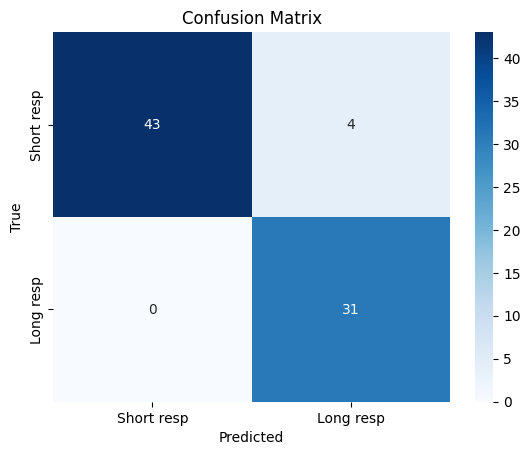

In [224]:
target_names = ['Short resp', 'Long resp']

y_pred = pipeline.predict(x)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Calculated SHAP values

In [225]:
model = pipeline[-1]

x_train_scaled = pipeline[:-1].transform(x_train)   # x -> preprocessed -> scaler
x_scaled = pipeline[:-1].transform(x)

preprocessed_feature_names = pipeline['preprocess'].get_feature_names_out()
feature_names = [
    n.replace('remainder__', '')
     .replace('m_stage__', '')
     .replace('categorical__', '')
     .replace('sex__', '')
     .replace('age__', '')
     .replace('drug_braf__', '')
    for n in pipeline['preprocess'].get_feature_names_out()
]

explainer = shap.LinearExplainer(model, x_train_scaled)   # pass only Train as background
shap_values = explainer(x_scaled)                         # explain both Train+Test
shap_values.feature_names = feature_names

In [226]:
shap_values

.values =
array([[ 0.32532948, -0.09748013, -0.07859714, ...,  0.03969551,
        -0.05215571, -0.10644776],
       [ 0.91857737,  0.11836873, -0.07859714, ...,  0.06210549,
         0.24470387,  0.01541977],
       [ 0.91857737, -0.09748013, -0.07859714, ..., -0.12154699,
         0.24760072,  0.15220051],
       ...,
       [-0.2679184 ,  0.11836873, -0.07859714, ..., -0.16018276,
        -0.47114836, -0.45043038],
       [-0.2679184 , -0.09748013, -0.07859714, ..., -0.26748344,
         0.01501222,  0.00492157],
       [-0.2679184 , -0.09748013, -0.07859714, ..., -0.07666055,
        -0.18769137, -0.0836041 ]], shape=(78, 34))

.base_values =
array([-0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.3971848, -0.3971848, -0.3971848, -0.3971848, -0.3971848,
       -0.

## Plot explanation

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


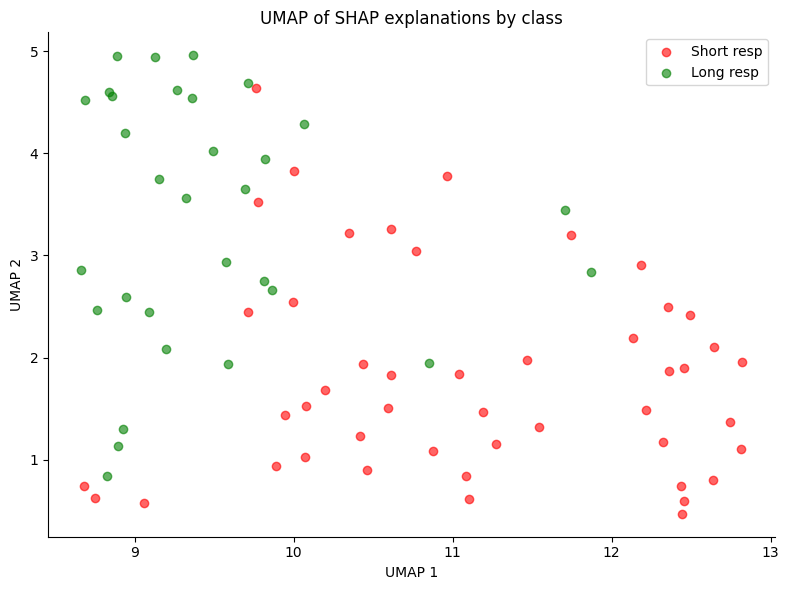

In [227]:
def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# # PCA — pass explained variance
# pca = PCA(n_components=2)
# sv_2d = pca.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=20, random_state=42)
# sv_2d = tsne.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# UMAP
u_map = umap.UMAP(n_components=2, random_state=42)
sv_2d = u_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# # PaCMAP
# pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
# sv_2d = pac_map.fit_transform(sv_input)
# plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")


## Global interpretability

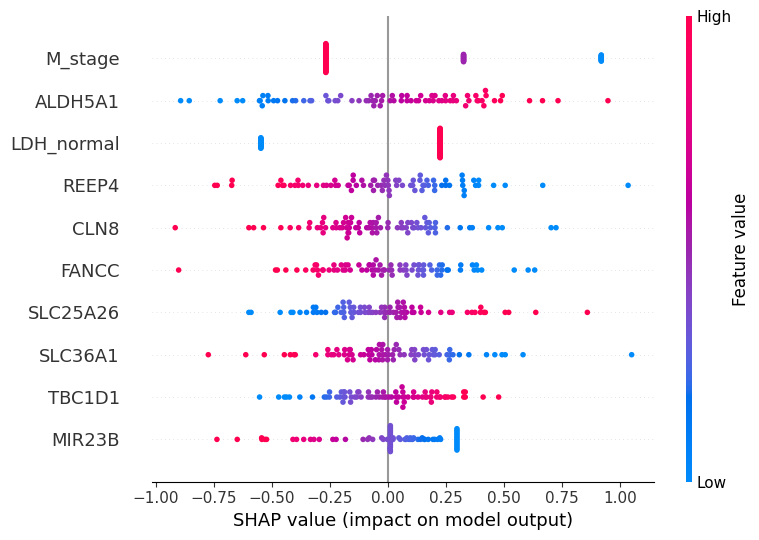

In [228]:
shap.summary_plot(shap_values, x_scaled, feature_names=feature_names, max_display=10)

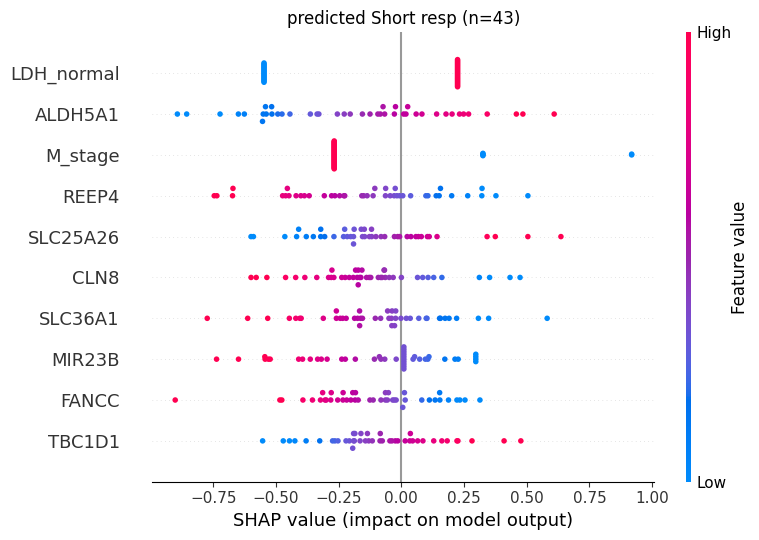

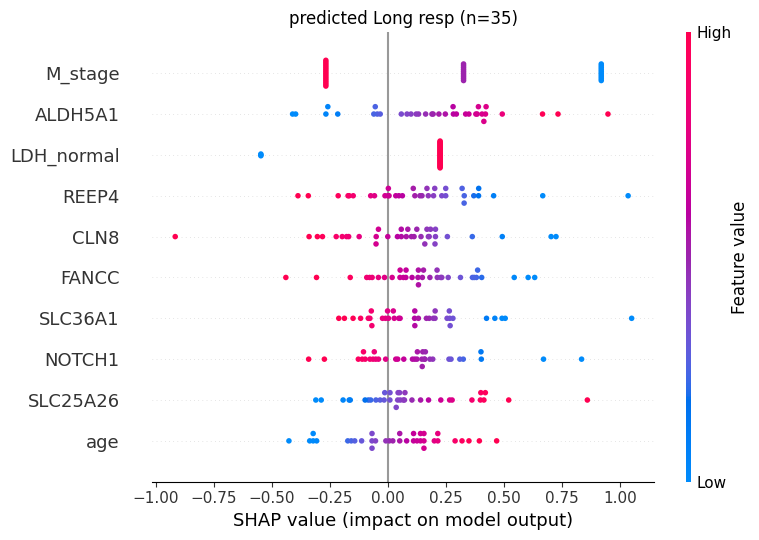

In [ ]:
# for cls, label in [(0, "Short resp"), (1, "Long resp")]:
#     mask = y_pred == cls
#     shap.summary_plot(
#         shap_values[mask],
#         x_scaled[mask],
#         feature_names=feature_names,
#         max_display=10,
#         show=False,
#     )
#     plt.title(f"predicted {label} (n={mask.sum()})")
#     plt.tight_layout()
#     plt.show()

## Local interpretability

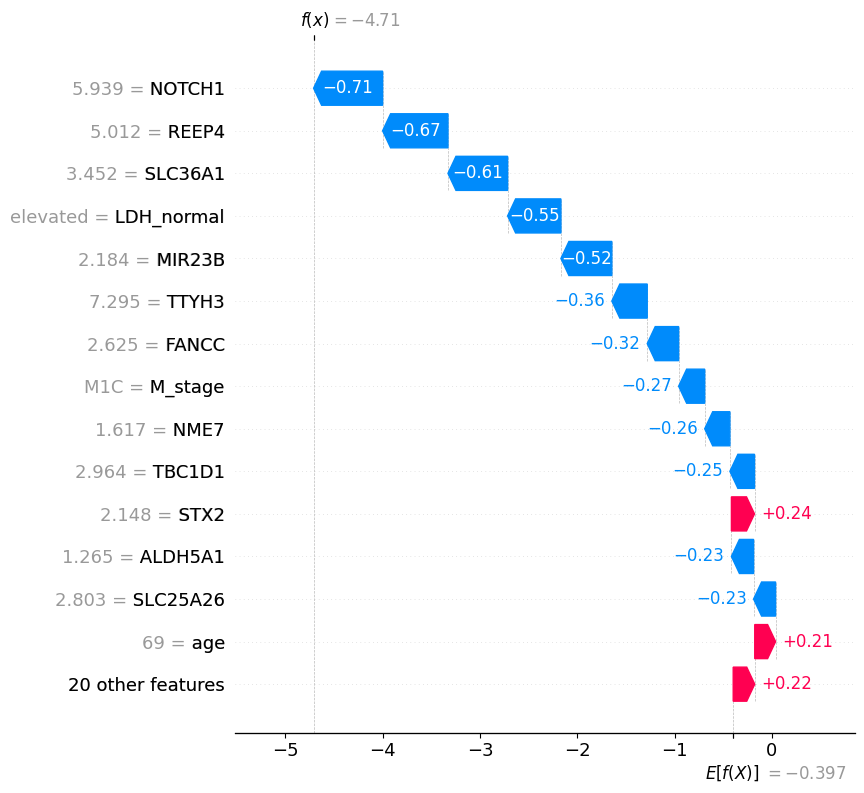

In [232]:
import copy
sv_raw = copy.copy(shap_values)
sv_raw.data = x.values

shap.plots.waterfall(sv_raw[tn[9]], max_display=15)

In [233]:
shap.initjs()
shap.plots.force(sv_raw[tn[35]]) # 9 7 23 35

In [234]:
shap.plots.force(sv_raw[tp[25]]) # 3 18 21 25

## Subgroups analysis: Kmeans

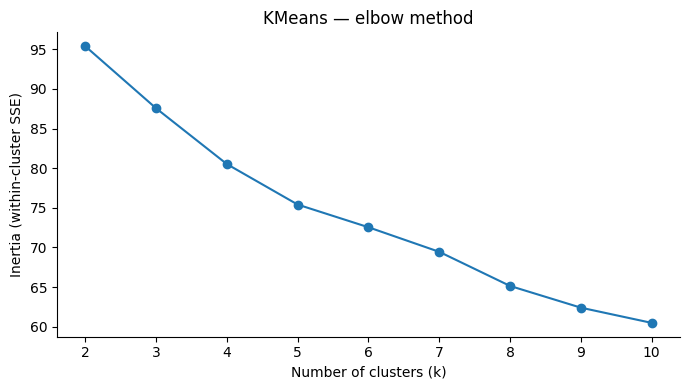

In [235]:
from sklearn.cluster import KMeans

# KMeans elbow
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sv_input)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("KMeans — elbow method")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
def plot_umap():
    cluster_colors = plt.cm.tab10.colors[:n_clusters]
    markers = {0: "o", 1: "^"}  # circle=short resp, triangle=long resp

    fig, ax = plt.subplots(figsize=(8, 6))

    for k in range(n_clusters):
        for cls in np.unique(y_arr):
            mask = (cluster_labels == k) & (y_arr == cls)
            label = f"Cluster {k} – {'Short resp' if cls == 0 else 'Long resp'}"
            ax.scatter(
                sv_2d[mask, 0], sv_2d[mask, 1],
                c=[cluster_colors[k]], marker=markers[cls],
                alpha=0.7, label=label, edgecolors="k", linewidths=0.4,
            )

    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(f"KMeans (k={n_clusters}) on SHAP values — UMAP \n(color = cluster, shape = true class)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

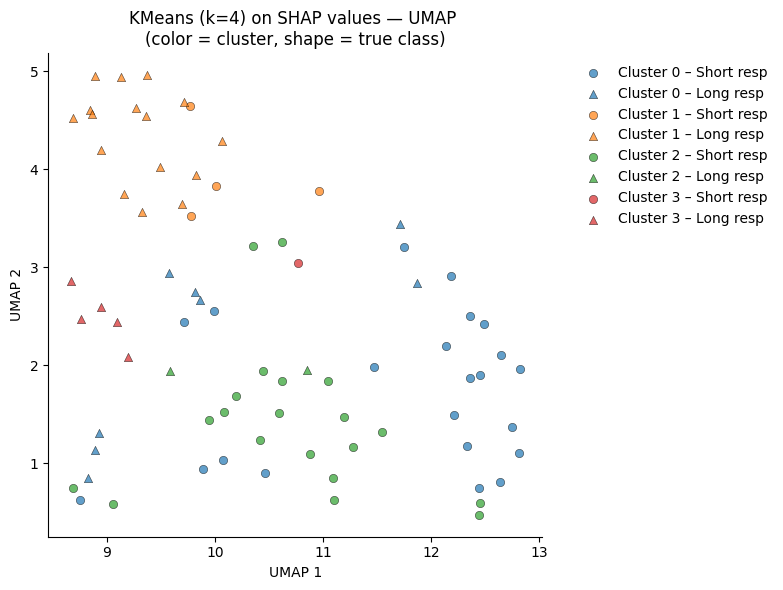

Cluster 0: 22 Short resp, 8 Long resp
Cluster 1: 4 Short resp, 16 Long resp
Cluster 2: 20 Short resp, 2 Long resp
Cluster 3: 1 Short resp, 5 Long resp


In [ ]:
from sklearn.cluster import KMeans

# cluster in full SHAP space, use sv_2d only for visualization
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(sv_input)

n_clusters = kmeans.n_clusters
cluster_colors = plt.cm.tab10.colors[:n_clusters]
markers = {0: "o", 1: "^"}  # circle=short resp, triangle=long resp

fig, ax = plt.subplots(figsize=(8, 6))

for k in range(n_clusters):
    for cls in np.unique(y_arr):
        mask = (cluster_labels == k) & (y_arr == cls)
        label = f"Cluster {k} – {'Short resp' if cls == 0 else 'Long resp'}"
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=[cluster_colors[k]], marker=markers[cls],
            alpha=0.7, label=label, edgecolors="k", linewidths=0.4,
        )

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title(f"KMeans (k={n_clusters}) on SHAP values — UMAP \n(color = cluster, shape = true class)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for k in range(n_clusters):
    mask = cluster_labels == k
    counts = pd.Series(y_arr[mask]).value_counts().sort_index()
    short = counts.get(0, 0)
    long  = counts.get(1, 0)
    print(f"Cluster {k}: {short} Short resp, {long} Long resp")


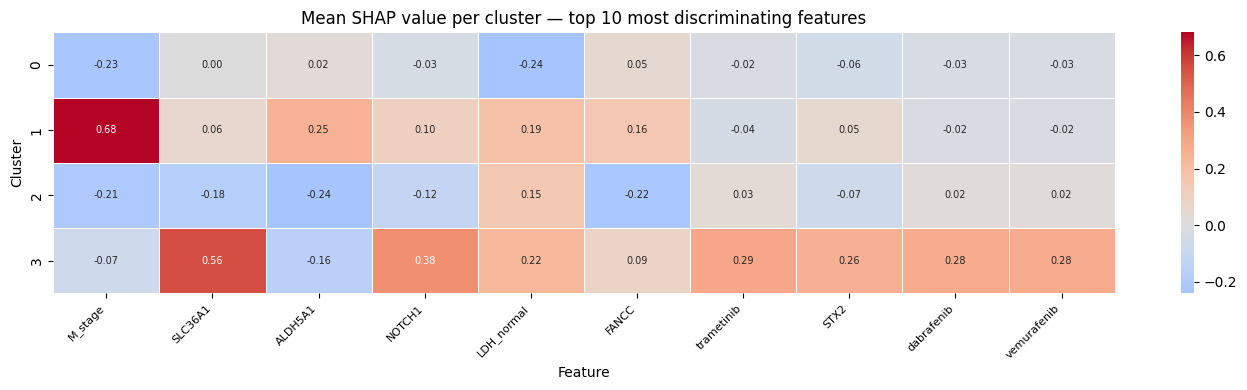

In [237]:
sv_df = pd.DataFrame(shap_values.values, columns=feature_names)
sv_df["cluster"] = cluster_labels

cluster_means = sv_df.groupby("cluster").mean()

# keep top 20 features with highest variance across clusters
top_features = cluster_means.std(axis=0).nlargest(10).index
heatmap_data = cluster_means[top_features]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, ax=ax,
)
ax.set_title(f"Mean SHAP value per cluster — top 10 most discriminating features")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## Subgroups analysis: Hierarchical clustering

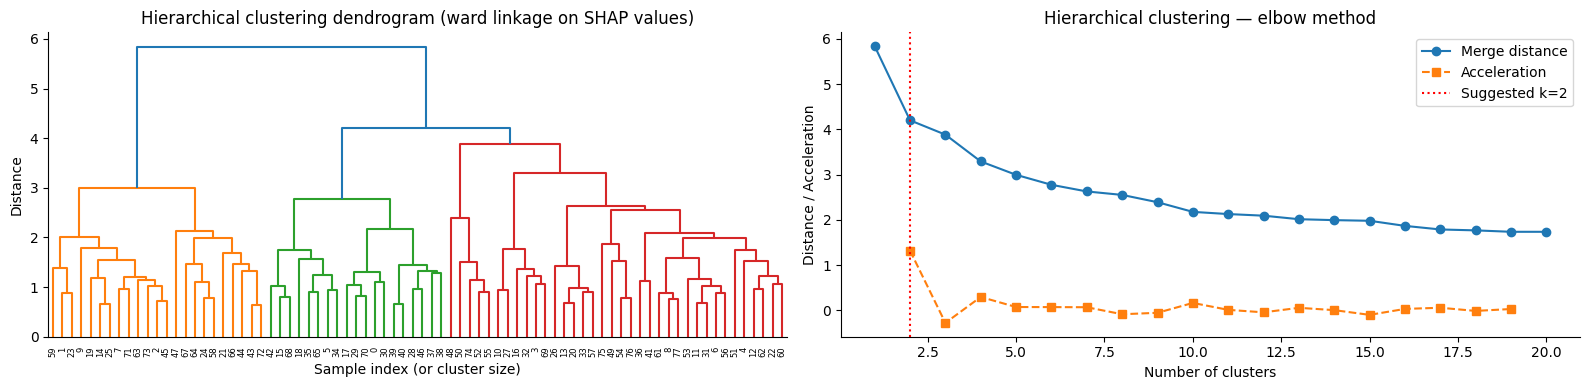

Suggested number of clusters (hierarchical): 2


In [238]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(sv_input, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Dendrogram
dendrogram(Z, ax=axes[0])
axes[0].set_title("Hierarchical clustering dendrogram (ward linkage on SHAP values)")
axes[0].set_xlabel("Sample index (or cluster size)")
axes[0].set_ylabel("Distance")
axes[0].spines[["top", "right"]].set_visible(False)

# Elbow: last merge distances and their acceleration
last = Z[-20:, 2][::-1]          # top 20 merge distances, largest first
acceleration = np.diff(last, 2)   # second derivative — peak = elbow
suggested_k = int(acceleration.argmax()) + 2
idxs = np.arange(1, len(last) + 1)

axes[1].plot(idxs, last, marker="o", label="Merge distance")
axes[1].plot(idxs[1:-1], acceleration, marker="s", linestyle="--", label="Acceleration")
axes[1].axvline(x=suggested_k, color="red", linestyle=":", label=f"Suggested k={suggested_k}")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Distance / Acceleration")
axes[1].set_title("Hierarchical clustering — elbow method")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Suggested number of clusters (hierarchical): {suggested_k}")

Number of clusters at threshold 3.8: 4


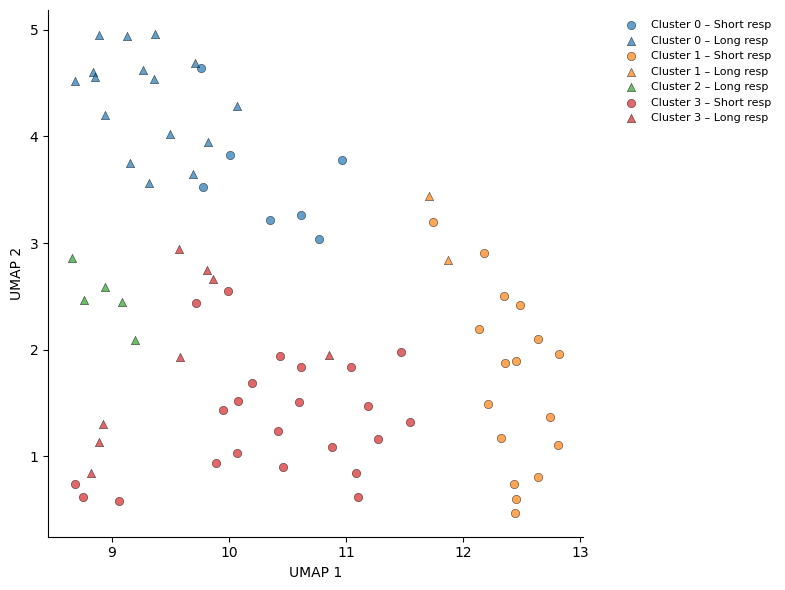

Cluster 0: 7 Short resp, 16 Long resp
Cluster 1: 17 Short resp, 2 Long resp
Cluster 2: 0 Short resp, 5 Long resp
Cluster 3: 23 Short resp, 8 Long resp


In [239]:
# --- cut at chosen distance threshold ---
dist_threshold = 3.8   # adjust based on dendrogram
hier_labels = fcluster(Z, t=dist_threshold, criterion="distance") - 1  # 0-indexed

n_hier = hier_labels.max() + 1
print(f"Number of clusters at threshold {dist_threshold}: {n_hier}")

hier_colors = plt.cm.tab10.colors[:n_hier]
markers = {0: "o", 1: "^"}

fig, ax = plt.subplots(figsize=(8, 6))

for k in range(n_hier):
    for cls in np.unique(y_arr):
        mask = (hier_labels == k) & (y_arr == cls)
        if mask.sum() == 0:
            continue
        cls_name = "Short resp" if cls == 0 else "Long resp"
        ax.scatter(sv_2d[mask, 0], sv_2d[mask, 1],
                   c=[hier_colors[k]], marker=markers[cls], alpha=0.7,
                   label=f"Cluster {k} – {cls_name}",
                   edgecolors="k", linewidths=0.4)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
# ax.set_title(f"Hierarchical clustering — UMAP\n(threshold={dist_threshold}, k={n_hier})")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

for k in range(n_hier):
    mask = hier_labels == k
    counts = pd.Series(y_arr[mask]).value_counts().sort_index()
    print(f"Cluster {k}: {counts.get(0,0)} Short resp, {counts.get(1,0)} Long resp")

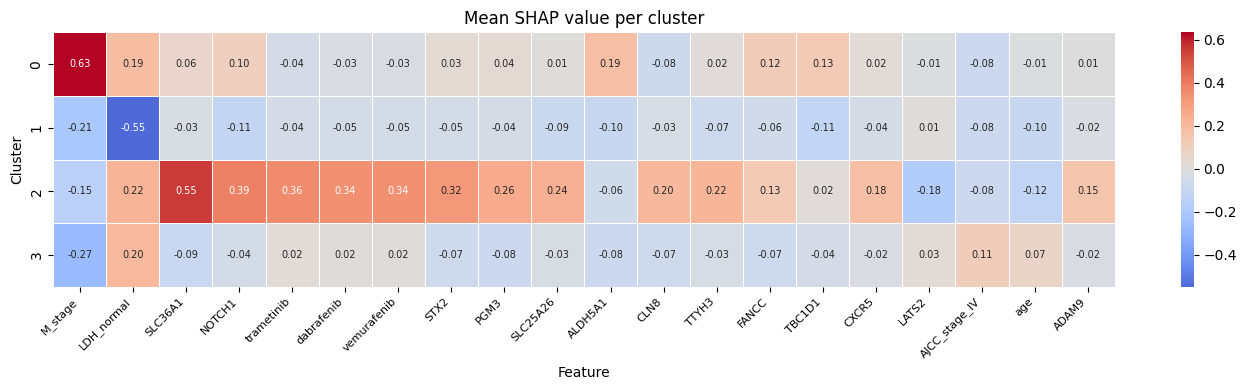

In [240]:
sv_df_hier = pd.DataFrame(shap_values.values, columns=feature_names)
sv_df_hier["cluster"] = hier_labels

cluster_means_hier = sv_df_hier.groupby("cluster").mean()

top_features_hier = cluster_means_hier.std(axis=0).nlargest(20).index
heatmap_data_hier = cluster_means_hier[top_features_hier]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heatmap_data_hier,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, ax=ax,
)
ax.set_title("Mean SHAP value per cluster")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

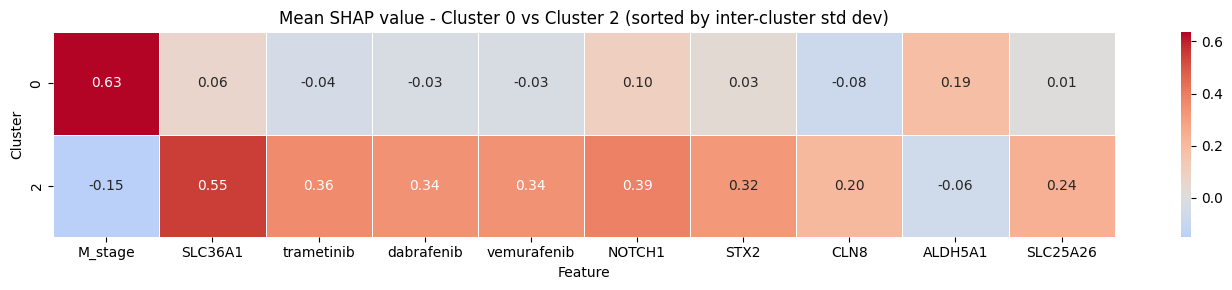

In [241]:
subset_clusters = [0, 2]
cluster_means_02 = cluster_means_hier.loc[subset_clusters]

top_features_02 = cluster_means_02.std(axis=0).nlargest(10).index
heatmap_data_02 = cluster_means_02[top_features_02]

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    heatmap_data_02,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f",
    linewidths=0.4, ax=ax,
)
ax.set_title("Mean SHAP value - Cluster 0 vs Cluster 2 (sorted by inter-cluster std dev)")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.xticks()
plt.tight_layout()
plt.show()

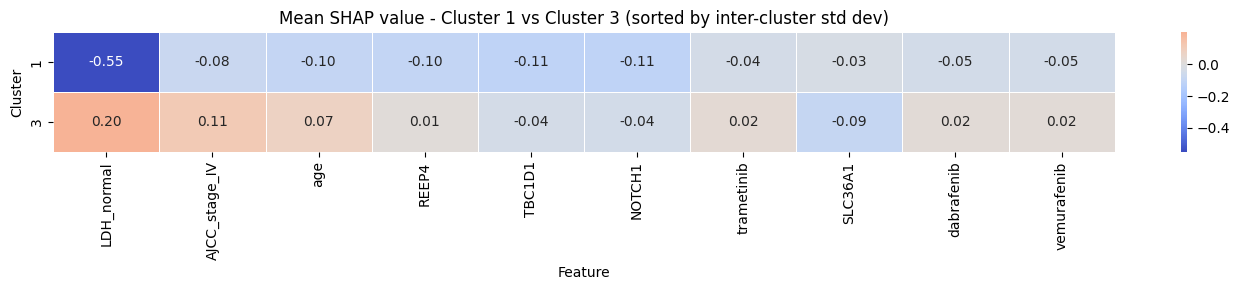

In [242]:
subset_clusters = [1, 3]
cluster_means_13 = cluster_means_hier.loc[subset_clusters]

top_features_13 = cluster_means_13.std(axis=0).nlargest(10).index
heatmap_data_13 = cluster_means_13[top_features_13]

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    heatmap_data_13,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f",
    linewidths=0.4, ax=ax,
)
ax.set_title("Mean SHAP value - Cluster 1 vs Cluster 3 (sorted by inter-cluster std dev)")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.xticks()
plt.tight_layout()
plt.show()

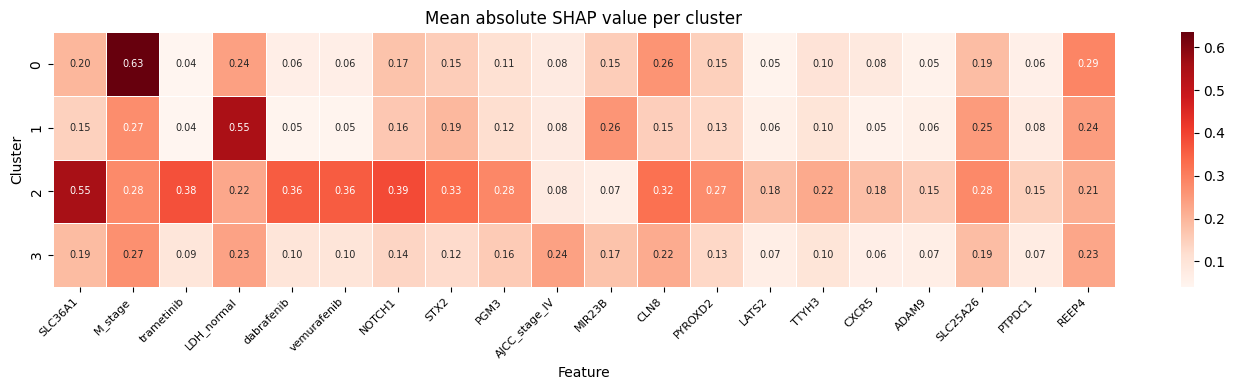

In [243]:
sv_df_hier_abs = sv_df_hier.drop(columns="cluster").abs()
sv_df_hier_abs["cluster"] = hier_labels

cluster_abs_means = sv_df_hier_abs.groupby("cluster").mean()

top_features_abs = cluster_abs_means.std(axis=0).nlargest(20).index
heatmap_data_abs = cluster_abs_means[top_features_abs]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heatmap_data_abs,
    cmap="Reds",
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, ax=ax,
)
ax.set_title("Mean absolute SHAP value per cluster")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

In [244]:
# for k in range(n_hier):
#     mask = hier_labels == k
#     counts = pd.Series(y_arr[mask]).value_counts().sort_index()
#     short, long_ = counts.get(0, 0), counts.get(1, 0)

#     shap.summary_plot(
#         shap_values[mask],
#         x_scaled[mask],
#         feature_names=feature_names,
#         max_display=10,
#         show=False,
#     )
#     plt.title(f"Cluster {k}  ({short} Short resp, {long_} Long resp)")
#     plt.tight_layout()
#     plt.show()

In [245]:
# def plot_cluster_shap(cluster_id: int):
#     """Plot SHAP summary split by true label for the given cluster."""
#     cluster_mask = hier_labels == cluster_id

#     for cls, resp_label in [(0, "Short resp"), (1, "Long resp")]:
#         mask = cluster_mask & (y_arr == cls)
#         n = mask.sum()
#         if n == 0:
#             print(f"No {resp_label} samples in cluster {cluster_id}, skipping.")
#             continue
        
#         shap.summary_plot(
#             shap_values[mask],
#             x_scaled[mask],
#             feature_names=feature_names,
#             max_display=10,
#             show=False,
#         )
#         plt.title(f"Cluster {cluster_id}: Predicted {resp_label} (n={n} samples)")
#         plt.tight_layout()
#         plt.show()

# plot_cluster_shap(0)


In [246]:
cA, cB = 0, 2  # the two long-responder-enriched hier clusters
maskA = (hier_labels == cA) & (y_arr == 1)
maskB = (hier_labels == cB) & (y_arr == 1)

pos_A = np.where(maskA)[0]
pos_B = np.where(maskB)[0]

print(x.iloc[pos_A][top_features_02.to_list()])
print(x.iloc[pos_B][top_features_02.to_list()])


   M_stage   SLC36A1  trametinib  dabrafenib  vemurafenib    NOTCH1      STX2  \
1      M1A  2.153561           0           0            1  3.629710  2.604217   
2      M1A  1.903797           0           0            1  2.587868  3.082058   
7      M1A  1.608639           0           0            1  3.428465  2.070689   
9      M1A  2.172463           0           0            1  2.503283  2.076454   
14     M1B  1.906188           0           0            1  2.004744  3.591494   
19     M1B  2.315014           0           0            1  2.711182  2.600262   
23     M1A  1.247663           0           0            1  3.239028  2.375626   
24     M1B  1.717924           0           0            1  3.579790  2.751674   
25     M1B  2.145117           0           0            1  3.038704  2.817965   
44     M1B  1.797837           0           0            1  0.612360  3.382255   
45     M1A  1.904396           0           0            1  2.593172  2.468046   
59     M1A  2.329961        

In [247]:
cA, cB = 1, 3  # the two short-responder-enriched hier clusters
maskA = (hier_labels == cA) & (y_arr == 0)
maskB = (hier_labels == cB) & (y_arr == 0)

pos_A = np.where(maskA)[0]
pos_B = np.where(maskB)[0]

# x_encoded has 0/1 binary values for categoricals (LDH_normal, AJCC_stage_IV, etc.)
# and raw values for numerics — more readable than scaled x_scaled_df
available_13 = [f for f in top_features_13 if f in x_encoded.columns]
print("Cluster 1 short-responders:")
print(x_encoded.iloc[pos_A][available_13])
print("\nCluster 3 short-responders:")
print(x_encoded.iloc[pos_B][available_13])

Cluster 1 short-responders:
    LDH_normal  AJCC_stage_IV  age     REEP4    TBC1D1    NOTCH1  trametinib  \
0        False           True   26  3.985531  3.450505  3.070871           0   
5        False           True   51  5.014304  3.185989  3.278240           0   
15       False           True   47  4.597446  2.656128  4.120365           0   
17       False           True   36  3.745731  3.177746  3.050507           0   
18       False           True   69  5.011666  2.964098  5.938888           0   
28       False           True   62  4.389733  3.106629  3.295093           0   
29       False           True   48  3.822185  3.041833  4.237081           0   
34       False           True   44  3.975538  3.392423  2.678992           0   
35       False           True   39  4.708735  3.115127  3.578943           0   
37       False           True   52  4.334745  4.731274  3.602243           0   
38       False           True   35  3.753683  4.259467  2.998315           0   
39       Fal

## Subgroups analysis: Skope-rules

In [248]:
from imodels import SkopeRulesClassifier

# One-hot encode categoricals so SkopeRules gets numeric input;
# get_dummies keeps names like "m_stage_M1B" which remain clinically readable.
x_encoded = pd.get_dummies(x).reset_index(drop=True)
feature_cols = list(x_encoded.columns)
x_raw = x_encoded.values.astype(float)

print("=" * 70)
print("Skope-Rules — decision rules per hierarchical cluster (raw features)")
print("=" * 70)

for k in range(n_hier):
    binary_target = (hier_labels == k).astype(int)
    n_pos = int(binary_target.sum())

    sr = SkopeRulesClassifier(
        precision_min=0.70,      # was 0.5 — catch more rules
        recall_min=0.55,         # was 0.5 — catch more rules
        random_state=42,
        n_estimators=50,         # was 10 — much more diverse rules
        max_depth=3,             # keep
        max_depth_duplication=2, # was 2 — allow slightly more overlap
        # max_features=0.8,        # add this — feature diversit
    )
    sr.fit(x_raw, binary_target, feature_names=feature_cols)

    counts = pd.Series(y_arr[hier_labels == k]).value_counts().sort_index()
    short, long_ = counts.get(0, 0), counts.get(1, 0)
    print(f"\nCluster {k}  ({n_pos} patients — {short} Short resp, {long_} Long resp)")
    print("-" * 50)

    if sr.rules_:
        for rule, (prec, rec, n) in sr.rules_:
            print(f"  IF {rule}")
            print(f"     → precision={prec:.2f}  recall={rec:.2f}  support={n}")
    else:
        print("  No rules found (try lowering precision_min / recall_min)")

Skope-Rules — decision rules per hierarchical cluster (raw features)

Cluster 0  (23 patients — 7 Short resp, 16 Long resp)
--------------------------------------------------
  IF AJCC_stage_IV > 0.5 and LDH_normal > 0.5 and M_stage_M1C <= 0.5
     → precision=1.00  recall=0.86  support=1
  IF M_stage_M1A > 0.5
     → precision=1.00  recall=0.68  support=11
  IF MIR23B <= 0.2205 and M_stage_M1A <= 0.5 and M_stage_M1B > 0.5
     → precision=1.00  recall=0.67  support=1
  IF ALDH5A1 <= 2.25133 and REEP4 > 3.48749 and TBC1D1 > 3.97324
     → precision=0.75  recall=0.60  support=1

Cluster 1  (19 patients — 17 Short resp, 2 Long resp)
--------------------------------------------------
  IF AJCC_stage_IV > 0.5 and LDH_elevated > 0.5 and M_stage_M1A <= 0.5
     → precision=1.00  recall=1.00  support=2
  IF LDH_elevated > 0.5 and M_stage_M1A <= 0.5 and PGM3 <= 4.07878
     → precision=1.00  recall=1.00  support=1
  IF CXCR5 <= 0.60794 and LDH_normal <= 0.5 and M_stage_M1C > 0.5
     → precisi